In [15]:
import os, sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from LAMP import Experiment

from ProfileCamAnalysis import ProfileCamAnalysis, Normalisation
from ROI import RectangleROI
from ProfileCamPlotting import plot_group_overview, plot_group_comparison

In [7]:
ROOT_FOLDER = str(Path.cwd().parent.parent)
sys.path.append(ROOT_FOLDER)
ex = Experiment(ROOT_FOLDER)

Using DAQ: FireballIII
Adding (User) Diagnostic: HRM5 [ESpec_]
Adding (User) Diagnostic: HRM6 [ESpec_]
Adding (User) Diagnostic: HRM3 [ProfileCam_]
Adding (User) Diagnostic: HRM4 [ProfileCam_]


In [8]:
shot_log = pd.read_csv("~/Documents/FIREBALLIII_ANALYSIS/BrynShotLog.csv")
def shotno_to_timestamp(shotnos, df):
    mapped = df.loc[df['Shot number'].isin(shotnos), 'Acquisition UNIX Timestamp of HiRadMat cycle (UTC timezone)'].tolist()
    return [int(s) for s in mapped]

In [18]:
HRM4 = ex.get_diagnostic('HRM4')

shot_groups = {
    "PPLW" : shotno_to_timestamp(list(range(169, 174)), shot_log),
    "PGLW" : shotno_to_timestamp(list(range(157, 162)), shot_log)
}

analysis = ProfileCamAnalysis(HRM4, "HRM4_calib.toml")
roi = RectangleROI(130, 160, 130, 250)

results = analysis.compare_groups(
    shot_groups,
    roi,
    Normalisation.AREA
)

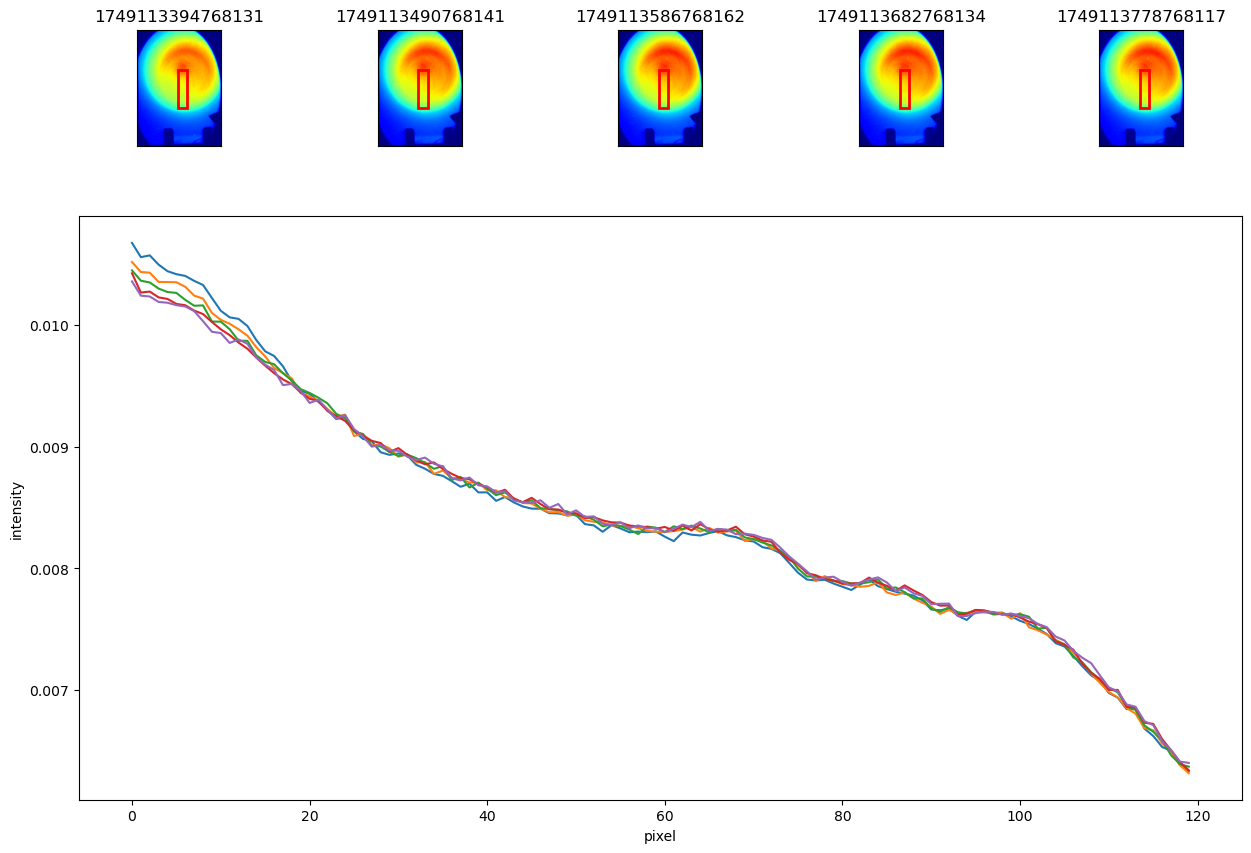

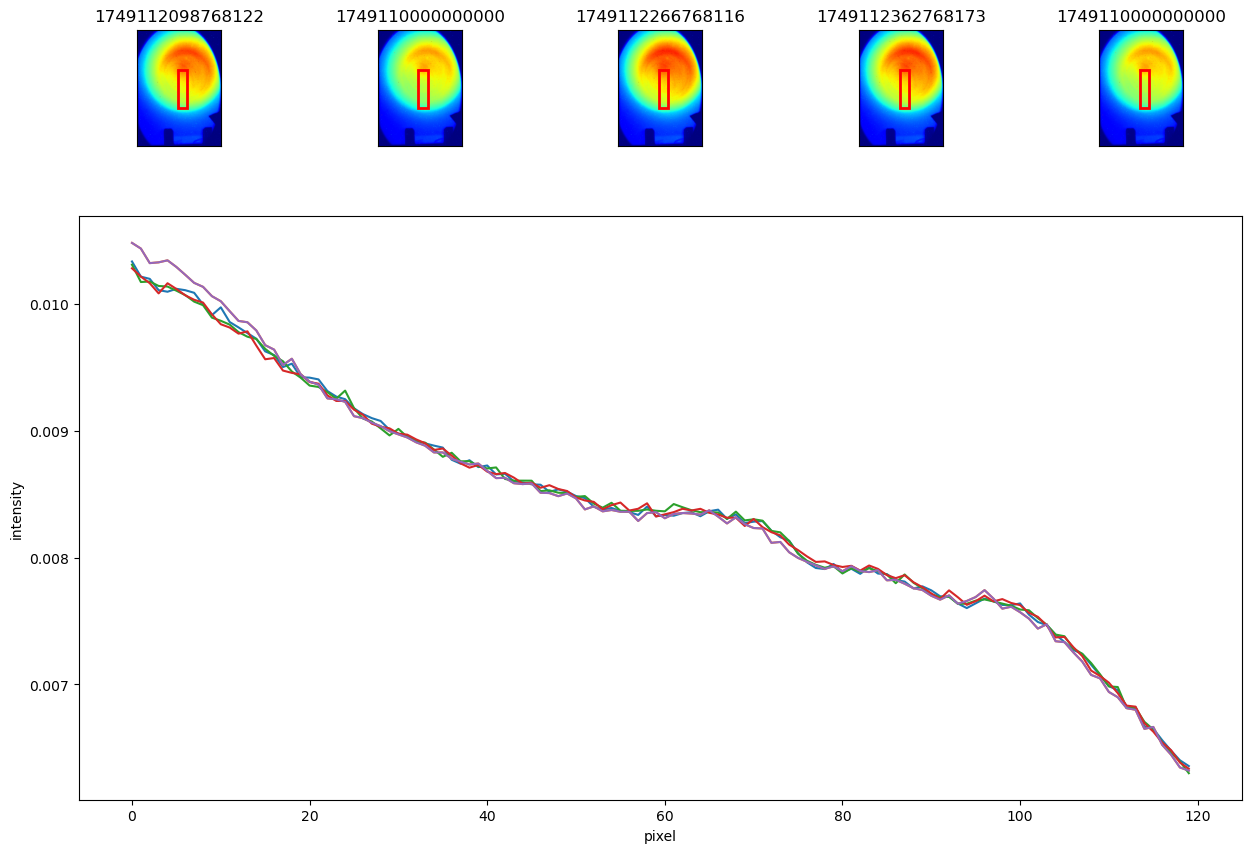

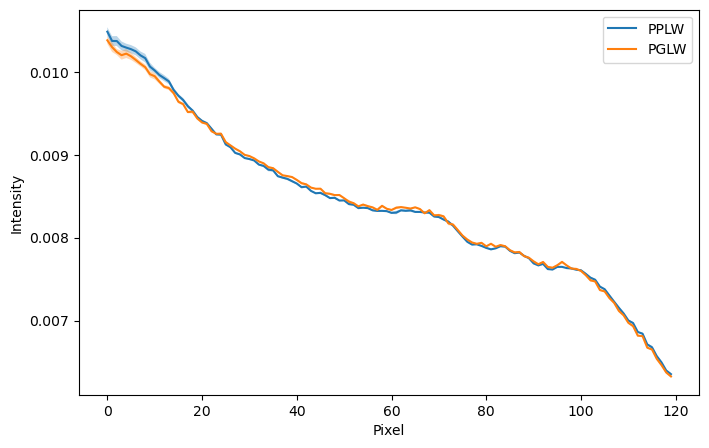

In [19]:
plot_group_overview(results["PPLW"], roi)
plot_group_overview(results["PGLW"], roi)
plot_group_comparison(results)